<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Week-02.-Tokens-and-N-Grams" data-toc-modified-id="Week-02.-Tokens-and-N-Grams-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Week 02. Tokens and N-Grams</a></span></li><li><span><a href="#Basic-Pre-Processing-and-Tokenization" data-toc-modified-id="Basic-Pre-Processing-and-Tokenization-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Basic Pre-Processing and Tokenization</a></span><ul class="toc-item"><li><span><a href="#Tagging-Parts-of-Speech" data-toc-modified-id="Tagging-Parts-of-Speech-2.1"><span class="toc-item-num">2.1&nbsp;&nbsp;</span>Tagging Parts of Speech</a></span></li></ul></li><li><span><a href="#Corpus-Prep-with-spaCy" data-toc-modified-id="Corpus-Prep-with-spaCy-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Corpus Prep with spaCy</a></span></li><li><span><a href="#N-grams" data-toc-modified-id="N-grams-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>N-grams</a></span></li><li><span><a href="#Tokenizers" data-toc-modified-id="Tokenizers-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>Tokenizers</a></span></li><li><span><a href="#Feature-Selection" data-toc-modified-id="Feature-Selection-6"><span class="toc-item-num">6&nbsp;&nbsp;</span>Feature Selection</a></span></li><li><span><a href="#Sentencepiece-Tokenization" data-toc-modified-id="Sentencepiece-Tokenization-7"><span class="toc-item-num">7&nbsp;&nbsp;</span>Sentencepiece Tokenization</a></span></li>
<li><span><a href="#Parsing" data-toc-modified-id="Parsing-8"><span class="toc-item-num">8&nbsp;&nbsp;</span>Parsing</a></span><ul class="toc-item"><li><span><a href="#Setup" data-toc-modified-id="Setup-8.1"><span class="toc-item-num">8.1&nbsp;&nbsp;</span>Setup</a></span></li><li><span><a href="#Dependency-Parsing-with-SpaCy" data-toc-modified-id="Dependency-Parsing-with-SpaCy-8.2"><span class="toc-item-num">8.2&nbsp;&nbsp;</span>Dependency Parsing with SpaCy</a></span></li></ul></li>
<li><span><a href="#Constituency-Parsing-with-SpaCy" data-toc-modified-id="Constituency-Parsing-with-SpaCy-9"><span class="toc-item-num">9&nbsp;&nbsp;</span>Constituency Parsing with SpaCy</a></span></li>
<li><span><a href="#Application" data-toc-modified-id="Application-10"><span class="toc-item-num">10&nbsp;&nbsp;</span>Application</a></span></li>
</ul></div>

# Week 02. Tokens and N-Grams

Natural Language Processing for Law and Social Science<br>
Elliott Ash, ETH Zurich

In [3]:
# set random seed
import numpy as np
np.random.seed(4)

In [4]:
#setup
import warnings; warnings.simplefilter('ignore')
%matplotlib inline
import pandas as pd
import nltk

In [3]:
# If you are using Google Colab, here's the code to load sc_cases_cleaned.pkl from local. 
from google.colab import files
uploaded = files.upload()

Saving sc_cases_cleaned.pkl to sc_cases_cleaned.pkl


In [5]:
# load cleaned data from lesson 1.
df = pd.read_pickle('sc_cases_cleaned.pkl',compression='gzip')
df.columns

Index(['case_name', 'opinion_type', 'date_standard', 'authorship',
       'x_republican', 'maj_judges', 'dissent_judges', 'topic_id',
       'cite_count', 'opinion_text', 'sentiments', 'year', 'log_cite_count'],
      dtype='object')

# Basic Pre-Processing and Tokenization

In [4]:
text = "Prof. Zurich hailed from Zurich. She got 3 M.A.'s from ETH."

**Sentence Tokenization**

**NLTK has a fast implementation that makes errors.**

In [5]:
import nltk
nltk.download('punkt')
from nltk import sent_tokenize
sentences = sent_tokenize(text) # split document into sentences
print(sentences)

['Prof. Zurich hailed from Zurich.', 'She got 3 M.A.', "'s from ETH."]


[nltk_data] Downloading package punkt to
[nltk_data]     /Users/joshuaberry/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


**spacy works better.**

**Install spacy and the English model if you have not already.**

In [ ]:
# !pip install spacy
# !python -m spacy download en_core_web_sm

In [6]:
# 
import spacy
nlp = spacy.load('en_core_web_sm')
doc = nlp(text)
sentences = list(doc.sents)
print(sentences)

[Prof. Zurich hailed from Zurich., She got 3 M.A.'s from ETH.]


**Removing capitalization.**

In [7]:
# Capitalization
text_lower = text.lower() # go to lower-case

In [8]:
#####
# Punctuation
#####

# recipe for fast punctuation removal
from string import punctuation
print ("punctuation:", punctuation)
punc_remover = str.maketrans('','',punctuation) 
text_nopunc = text_lower.translate(punc_remover)
print(text_nopunc)

punctuation: !"#$%&'()*+,-./:;<=>?@[\]^_`{|}~
prof zurich hailed from zurich she got 3 mas from eth


In [9]:
# Tokens
tokens = text_nopunc.split() # splits a string on white space
print(tokens)

['prof', 'zurich', 'hailed', 'from', 'zurich', 'she', 'got', '3', 'mas', 'from', 'eth']


In [10]:
# Numbers
# remove numbers (keep if not a digit)
no_numbers = [t for t in tokens if not t.isdigit()]
# keep if not a digit, else replace with "#"
norm_numbers = [t if not t.isdigit() else '#' 
                for t in tokens ]
print(no_numbers )
print(norm_numbers)

['prof', 'zurich', 'hailed', 'from', 'zurich', 'she', 'got', 'mas', 'from', 'eth']
['prof', 'zurich', 'hailed', 'from', 'zurich', 'she', 'got', '#', 'mas', 'from', 'eth']


In [11]:
# Stopwords
nltk.download('stopwords')
from nltk.corpus import stopwords
stoplist = stopwords.words('english') 
print ("stop words:", stoplist)
# keep if not a stopword
nostop = [t for t in norm_numbers if t not in stoplist]
print(nostop)

stop words: ['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "s

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/joshuaberry/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [12]:
# scikit-learn stopwords
# depending on sklearn version, for sklearn==0.24.1, stop_words are here
from sklearn.feature_extraction._stop_words import ENGLISH_STOP_WORDS as stop_words
sorted(list(stop_words))[:20]

# in older versions, one may have to import it like this
# from sklearn.feature_extraction import stop_words
# sorted(list(stop_words.ENGLISH_STOP_WORDS))[:20]

['a',
 'about',
 'above',
 'across',
 'after',
 'afterwards',
 'again',
 'against',
 'all',
 'almost',
 'alone',
 'along',
 'already',
 'also',
 'although',
 'always',
 'am',
 'among',
 'amongst',
 'amoungst']

In [13]:
# spacy stopwords
sorted(list(nlp.Defaults.stop_words))[:20]

["'d",
 "'ll",
 "'m",
 "'re",
 "'s",
 "'ve",
 'a',
 'about',
 'above',
 'across',
 'after',
 'afterwards',
 'again',
 'against',
 'all',
 'almost',
 'alone',
 'along',
 'already',
 'also']

In [14]:
# Stemming
from nltk.stem import SnowballStemmer
stemmer = SnowballStemmer('english') # snowball stemmer, english
# remake list of tokens, replace with stemmed versions
tokens_stemmed = [stemmer.stem(t) for t in tokens]
print(tokens_stemmed)

['prof', 'zurich', 'hail', 'from', 'zurich', 'she', 'got', '3', 'mas', 'from', 'eth']


In [15]:
stemmer = SnowballStemmer('german') # snowball stemmer, german
print(stemmer.stem("Autobahnen"))

autobahn


In [16]:
# Lemmatizing
nltk.download('wordnet')
nltk.download('omw-1.4')
from nltk.stem import WordNetLemmatizer
wnl = WordNetLemmatizer()
wnl.lemmatize('corporation'), wnl.lemmatize('corporations')

[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/joshuaberry/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/joshuaberry/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


('corporation', 'corporation')

Let's wrap it into a recipe.

In [17]:
from string import punctuation
translator = str.maketrans('','',punctuation) 
from nltk.corpus import stopwords
stoplist = set(stopwords.words('english'))
from nltk.stem import SnowballStemmer
stemmer = SnowballStemmer('english')

def normalize_text(doc):
    "Input doc and return clean list of tokens"
    doc = doc.replace('\r', ' ').replace('\n', ' ')
    lower = doc.lower() # all lower case
    nopunc = lower.translate(translator) # remove punctuation
    words = nopunc.split() # split into tokens
    nostop = [w for w in words if w not in stoplist] # remove stopwords
    no_numbers = [w if not w.isdigit() else '#' for w in nostop] # normalize numbers
    stemmed = [stemmer.stem(w) for w in no_numbers] # stem each word
    return stemmed

And apply it to the Supreme Court Cases Corpus.

In [18]:
df['tokens_cleaned'] = df['opinion_text'].apply(normalize_text)
df['tokens_cleaned']

345    [chief, justic, robert, deliv, opinion, court,...
696    [justic, oconnor, deliv, opinion, court, petit...
656    [justic, ginsburg, deliv, opinion, court, peti...
549    [justic, steven, deliv, opinion, court, americ...
790    [justic, oconnor, deliv, opinion, court, case,...
                             ...                        
313    [justic, ginsburg, deliv, opinion, court, fede...
245    [justic, souter, deliv, opinion, court, author...
244    [justic, kennedi, deliv, opinion, court, quest...
438    [chief, justic, robert, deliv, opinion, court,...
500    [chief, justic, robert, deliv, opinion, court,...
Name: tokens_cleaned, Length: 768, dtype: object

**Shortcut: `gensim.simple_preprocess`.**



In [21]:
from gensim.utils import simple_preprocess # lowercase, tokenized, punctuations/numbers removed
print(simple_preprocess(text))

['prof', 'zurich', 'hailed', 'from', 'zurich', 'she', 'got', 'from', 'eth']


In [22]:
from collections import Counter
print(Counter(simple_preprocess(text)))

Counter({'zurich': 2, 'from': 2, 'prof': 1, 'hailed': 1, 'she': 1, 'got': 1, 'eth': 1})


Now let's `simple_preprocess` on the Supreme Court corpus.

In [23]:
df['tokens_simple'] = df['opinion_text'].apply(simple_preprocess)
df['tokens_simple']

345    [chief, justice, roberts, delivered, the, opin...
696    [justice, connor, delivered, the, opinion, of,...
656    [justice, ginsburg, delivered, the, opinion, o...
549    [justice, stevens, delivered, the, opinion, of...
790    [justice, connor, delivered, the, opinion, of,...
                             ...                        
313    [justice, ginsburg, delivered, the, opinion, o...
245    [justice, souter, delivered, the, opinion, of,...
244    [justice, kennedy, delivered, the, opinion, of...
438    [chief, justice, roberts, delivered, the, opin...
500    [chief, justice, roberts, delivered, the, opin...
Name: tokens_simple, Length: 768, dtype: object

**More customized preprocessing: `gensim.parsing.preprocessing_string` with filters.**

In [24]:
complicated_text = "<div>Prof. Zurich <i>hailed</i> from Zurich., She got 3 M.A.'s from ETH.</div>" # added html tags

from gensim.parsing.preprocessing import preprocess_string, \
strip_tags, strip_punctuation, strip_multiple_whitespaces, strip_numeric, remove_stopwords, strip_short, stem_text

preprocess_string(complicated_text) # with all default filters: lowercase, tags, puncations, whitespaces, numerics, short words, stop words.

['prof', 'zurich', 'hail', 'zurich', 'got', 'eth']

In [25]:
# remove some filters to keep more tokens.
# e.g. If I want to keep stopwords, short words, and numbers and keep the words not stemmed
CUSTOM_FILTERS = [lambda x: x.lower(), strip_tags, strip_punctuation, strip_multiple_whitespaces]
preprocess_string(complicated_text, CUSTOM_FILTERS) # only use the customized filters

['prof',
 'zurich',
 'hailed',
 'from',
 'zurich',
 'she',
 'got',
 '3',
 'm',
 'a',
 's',
 'from',
 'eth']

## Tagging Parts of Speech

In [26]:
text = 'Science cannot solve the ultimate mystery of nature. And that is because, in the last analysis, we ourselves are a part of the mystery that we are trying to solve.'

nltk.download('averaged_perceptron_tagger')
from nltk.tag import perceptron 
from nltk import word_tokenize
tagger = perceptron.PerceptronTagger()
tokens = word_tokenize(text)
tagged_sentence = tagger.tag(tokens)
tagged_sentence

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/joshuaberry/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.


[('Science', 'NN'),
 ('can', 'MD'),
 ('not', 'RB'),
 ('solve', 'VB'),
 ('the', 'DT'),
 ('ultimate', 'JJ'),
 ('mystery', 'NN'),
 ('of', 'IN'),
 ('nature', 'NN'),
 ('.', '.'),
 ('And', 'CC'),
 ('that', 'DT'),
 ('is', 'VBZ'),
 ('because', 'RB'),
 (',', ','),
 ('in', 'IN'),
 ('the', 'DT'),
 ('last', 'JJ'),
 ('analysis', 'NN'),
 (',', ','),
 ('we', 'PRP'),
 ('ourselves', 'PRP'),
 ('are', 'VBP'),
 ('a', 'DT'),
 ('part', 'NN'),
 ('of', 'IN'),
 ('the', 'DT'),
 ('mystery', 'NN'),
 ('that', 'IN'),
 ('we', 'PRP'),
 ('are', 'VBP'),
 ('trying', 'VBG'),
 ('to', 'TO'),
 ('solve', 'VB'),
 ('.', '.')]

Plot nouns and adjectives over time.

<Axes: xlabel='year'>

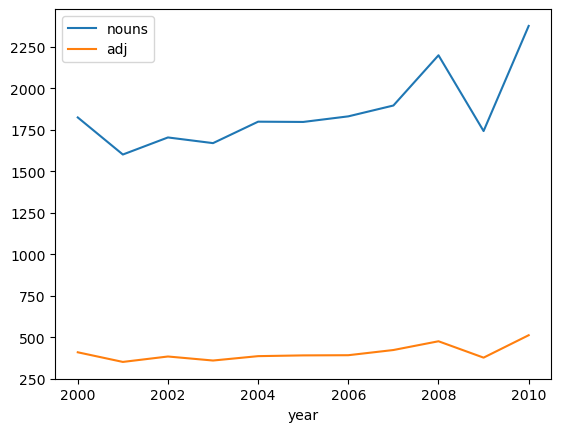

In [27]:
from collections import Counter
from nltk import word_tokenize

def get_nouns_adj(snippet):
    tags = [x[1] for x in tagger.tag(word_tokenize(snippet))]
    num_nouns = len([t for t in tags if t[0] == 'N'])
    num_adj = len([t for t in tags if t[0] == 'J'])
    return num_nouns, num_adj

df['nouns'], df['adj'] = zip(*df['opinion_text'].map(get_nouns_adj))
df.groupby('year')[['nouns','adj']].mean().plot()

In [28]:
# Get list of nouns, adjectives, and verbs from WordNet
# nltk.download('wordnet')
from nltk.corpus import wordnet as wn

nouns = set([x.lemma_names()[0].lower() 
             for x in wn.all_synsets('n')])

adjectives = set([x.lemma_names()[0].lower() 
             for x in wn.all_synsets('a')])

verbs = set([x.lemma_names()[0].lower() 
             for x in wn.all_synsets('v')])

In [29]:
for i, n in enumerate(nouns):
  print (n)
  if i >= 10:
    break

turf_war
stun_gun
river_prawn
mallee
reactionary
savings_bond
spadefoot
night_raven
arch_support
dimpled_chad
brigandine


# Corpus Prep with spaCy

Get spacy documents for each speech and add to dataframe. This is quicker than iterating over the dataframe with `iterrows()`, but slower than a parallelized solution. It will take a few minutes for a whole corpus.

In [30]:
dfs = df.sample(10)
dfs['doc'] = dfs['opinion_text'].apply(nlp)

In [31]:
# The spacy model already gives you sentences and tokens.
# For example:
sent1 = list(dfs['doc'].iloc[0].sents)[1]
sent1 # sentence

The Constitution's Compensation Clause guarantees federal judges a "Compensation, which shall not be diminished during their Continuance in Office."

In [32]:
# tokens
list(sent1) 

[The,
 Constitution,
 's,
 Compensation,
 Clause,
 guarantees,
 federal,
 judges,
 a,
 ",
 Compensation,
 ,,
 which,
 shall,
 not,
 be,
 diminished,
 during,
 their,
 Continuance,
 in,
 Office,
 .,
 "]

In [33]:
# lemmas
[x.lemma_ for x in sent1]

['the',
 'Constitution',
 "'s",
 'Compensation',
 'Clause',
 'guarantee',
 'federal',
 'judge',
 'a',
 '"',
 'Compensation',
 ',',
 'which',
 'shall',
 'not',
 'be',
 'diminish',
 'during',
 'their',
 'Continuance',
 'in',
 'Office',
 '.',
 '"']

In [34]:
# POS tags
[x.tag_ for x in sent1]

['DT',
 'NNP',
 'POS',
 'NNP',
 'NNP',
 'VBZ',
 'JJ',
 'NNS',
 'DT',
 '``',
 'NNP',
 ',',
 'WDT',
 'MD',
 'RB',
 'VB',
 'VBN',
 'IN',
 'PRP$',
 'NNP',
 'IN',
 'NNP',
 '.',
 "''"]

Analyzing a Corpus with spaCy data

In [35]:
dfs['num_words'] = dfs['doc'].apply(lambda x: len(list(x)))
dfs['num_sents'] = dfs['doc'].apply(lambda x: len(list(x.sents)))


print(len(tokens),'words in corpus.')
words_per_sent = len(tokens) / len(sentences)
print(words_per_sent,'words per sentence.')

35 words in corpus.
17.5 words per sentence.


**pre-processing with spacy**

In [36]:
def tokenize(x, nlp):
    # lemmatize and lowercase without stopwords, punctuation and numbers
    return [w.lemma_.lower() for w in nlp(x) if not w.is_stop and not w.is_punct and not w.is_digit]
tokenize(text, nlp)

['science',
 'solve',
 'ultimate',
 'mystery',
 'nature',
 'analysis',
 'mystery',
 'try',
 'solve']

# N-grams

In [43]:
from nltk import ngrams
from collections import Counter

# get n-gram counts for 10 documents
grams = []
for i, row in df.iterrows():
    tokens = row['opinion_text'].lower().split() # get tokens
    for n in range(2,4):
        grams += list(ngrams(tokens,n)) # get bigrams, trigrams, and quadgrams
    if i > 50:
        break
Counter(grams).most_common()[:8]  # most frequent n-grams

[(('of', 'the'), 23),
 (('the', 'tax'), 16),
 (('s.', 'ct.'), 16),
 (('l.', 'ed.'), 16),
 (('ed.', '2d'), 16),
 (('l.', 'ed.', '2d'), 16),
 (('in', 'the'), 15),
 (('§', '6404(e)(1)'), 14)]

# Tokenizers

In [44]:
# Counter is a quick pure-python solution.
from collections import Counter
freqs = Counter(tokens)
freqs.most_common()[:20]

[('the', 151),
 ('of', 92),
 ('to', 75),
 ('in', 48),
 ('§', 41),
 ('a', 39),
 ('that', 35),
 ('for', 31),
 ('and', 29),
 ('tax', 28),
 ('court', 22),
 ('is', 19),
 ('or', 19),
 ('review', 19),
 ('not', 18),
 ('interest', 17),
 ('6404(e)(1)', 16),
 ('v.', 16),
 ('s.', 16),
 ('ct.', 16)]

Usually we use scikit-learn's vectorizer.

In [45]:
from sklearn.feature_extraction.text import CountVectorizer
vec = CountVectorizer(min_df=0.01, # at min 1% of docs
                        max_df=.9,  
                        max_features=1000,
                        stop_words='english',
                        ngram_range=(1,3))
X = vec.fit_transform(df['opinion_text'])

# save the vectors
pd.to_pickle(X,'X.pkl')

# save the vectorizer 
# (so you can transform other documents, 
# also for the vocab)
pd.to_pickle(vec, 'vec-3grams-1.pkl')

In [46]:
# tf-idf vectorizer up-weights rare/distinctive words
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(min_df=0.01, 
                        max_df=0.9,  
                        max_features=1000,
                        stop_words='english',
                        use_idf=True, # the new piece
                        ngram_range=(1,2))

X_tfidf = tfidf.fit_transform(df['opinion_text'])
pd.to_pickle(X_tfidf,'X_tfidf.pkl')

# save from colab to local:
# from google.colab import files
# files.download("X.pkl")
# files.download("vec-3grams-1.pkl")
# files.download("X_tfidf.pkl")

**Make word cloud of common words by topic id.**

In [47]:
df['topic_id'].value_counts() 

topic_id
1.0     217
8.0     153
2.0     117
9.0      90
3.0      53
10.0     49
4.0      24
5.0      18
12.0     14
7.0      14
6.0      12
11.0      5
13.0      2
Name: count, dtype: int64

In [48]:
vocab = tfidf.get_feature_names_out()
vocab[:10], vocab[-10:]

(array(['000', '10', '100', '101', '102', '103', '103 ct', '104', '104 ct',
        '105'], dtype=object),
 array(['waters', 'way', 'west', 'word', 'words', 'work', 'writ', 'year',
        'years', 'york'], dtype=object))

1


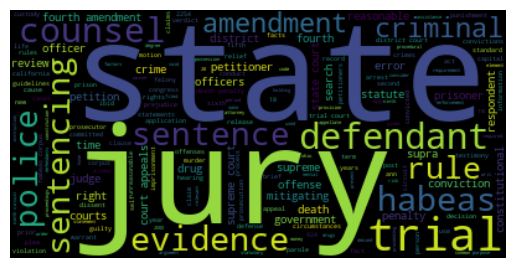

2


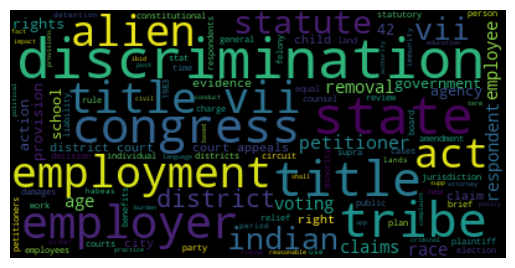

8


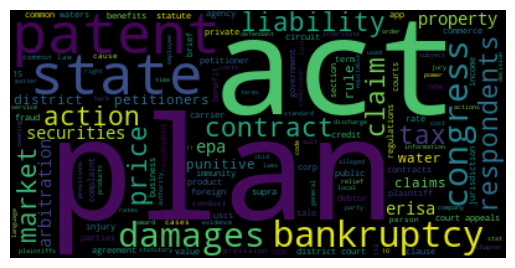

9


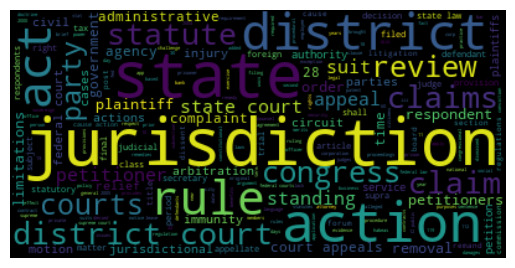

In [49]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

for topic_id in [1,2,8,9]: 
    slicer = df['topic_id'] == topic_id
    f = X_tfidf[slicer.values]
    total_freqs = list(np.array(f.sum(axis=0))[0])
    fdict = dict(zip(vocab,total_freqs))
    # generate word cloud of words with highest counts
    wordcloud = WordCloud().generate_from_frequencies(fdict) 
    print(topic_id)
    plt.clf()
    plt.imshow(wordcloud, interpolation='bilinear') 
    plt.axis("off") 
    plt.show()

**Make word cloud of common words by naive bayes topic ranking.**

In [53]:
from sklearn.naive_bayes import MultinomialNB
nb = MultinomialNB()
# X is the data transformed by CountVectorizer above, y are the topic_ids
print (X.shape, df['topic_id'].astype(int))
nb.fit(X.toarray(), df['topic_id'].astype(int))
df["topic_id"].describe()
print (nb.feature_log_prob_.shape)

(768, 1000) 345    12
696     9
656     9
549     2
790    10
       ..
313     9
245     9
244     5
438     8
500     1
Name: topic_id, Length: 768, dtype: int64
(13, 1000)


1


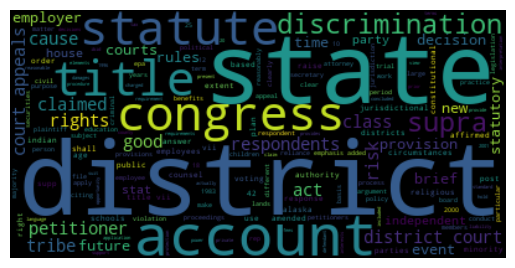

2


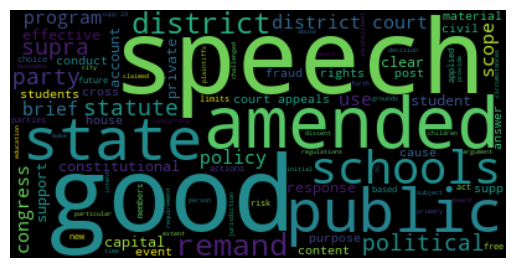

8


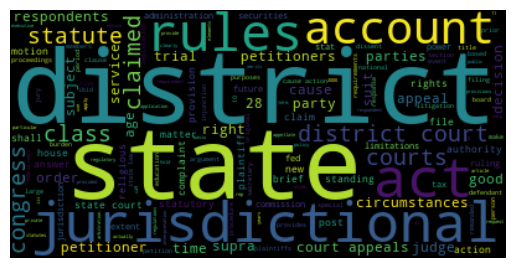

9


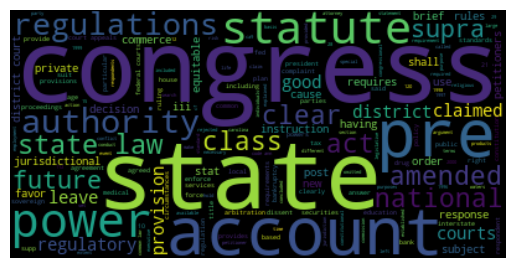

In [54]:
for topic_id in [1,2,8,9]: 
    # get feature coefficients for topic_id from naive bayes classifier
    f = nb.feature_log_prob_[topic_id]
    fdict = dict(zip(vocab,f))
    # generate word cloud of words with highest feature coefficients
    wordcloud = WordCloud().generate_from_frequencies(fdict) 
    print(topic_id)
    plt.clf()
    plt.imshow(wordcloud, interpolation='bilinear') 
    plt.axis("off") 
    plt.show()

**customer tokenizers and stemmers**

In [55]:
# hash vectorizer
from sklearn.feature_extraction.text import HashingVectorizer

hv = HashingVectorizer(n_features=10) # faster, save more storage etc.
X_hash = hv.fit_transform(df['opinion_text']) # However, you cannot recover original words from hashed features
X_hash

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 7680 stored elements and shape (768, 10)>

In [56]:
# dict vectorizer
# from sklearn.feature_extraction import DictVectorizer
#TODO make this work
#dv = DictVectorizer()
#X_dv = dv.fit_transform(df['opinion_text'])
#X_dv

**debugging hashing vectorizer**

In [59]:
!pip install eli5
from eli5.sklearn import InvertableHashingVectorizer

ivec = InvertableHashingVectorizer(hv)
inverted_hv = ivec.fit(df['opinion_text'])
print (len(inverted_hv.get_feature_names_out()))
print (len(inverted_hv.get_feature_names_out()[0]))
print (inverted_hv.get_feature_names_out()[0][:10])

10
5023
[{'name': np.str_('with'), 'sign': np.float64(-1.0)}, {'name': np.str_('has'), 'sign': np.float64(-1.0)}, {'name': np.str_('united'), 'sign': np.float64(1.0)}, {'name': np.str_('if'), 'sign': np.float64(1.0)}, {'name': np.str_('other'), 'sign': np.float64(-1.0)}, {'name': np.str_('whether'), 'sign': np.float64(-1.0)}, {'name': np.str_('because'), 'sign': np.float64(1.0)}, {'name': np.str_('when'), 'sign': np.float64(1.0)}, {'name': np.str_('supra'), 'sign': np.float64(1.0)}, {'name': np.str_('against'), 'sign': np.float64(1.0)}]


**hashing with keras**

In [62]:
!pip install keras
!pip install tensorflow
import tensorflow as tf
import keras
text = "Prof. Zurich hailed from Zurich. She got 3 M.A.'s from ETH."
n = 5 # num features
tf.keras.preprocessing.text.hashing_trick(
    text, n, hash_function=None,
    filters='!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n',
    lower=True, split=' '
)

  Using cached tensorflow-2.21.0-cp311-cp311-macosx_12_0_arm64.whl.metadata (4.4 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-1-py2.py3-none-macosx_11_0_arm64.whl.metadata (5.2 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached protobuf-7.34.1-cp310-abi3-macosx_10_9_universal2.whl.metadata (595 bytes)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached grpcio-1.80.0-cp311-cp311-macosx_11_0_universal2.whl.metadata (3.8 kB)
  Using cached h5py-3.14.0-cp311-cp311-macosx_11_0_arm64.whl.metadata (2.7 kB)
Using cached tensorflow-2.21.0-cp311-cp311-macosx_12_0_arm64.whl (223.4 MB)
Using cached grpcio-1.80.0-cp311-cp311-macosx_11_0_universal2.whl (12.0 MB)
Using cach

[2, 4, 4, 3, 4, 3, 4, 4, 3, 1, 3, 3, 2]

**Collocations: Point-Wise Mutual Information.**

In [63]:
from operator import mul
from functools import reduce
from nltk.stem import SnowballStemmer
stemmer = SnowballStemmer('english')

def get_gmean(phrase, termfreqs):
    words = phrase.split('_')
    n = len(words)
    p = [termfreqs[w]**(1/n) for w in words]
    # print (words, n, p)
    numerator = termfreqs[phrase]   
    denominator = reduce(mul, p)
    # print (numerator, denominator)
    if denominator == 0:
        return 0
    gmean = numerator / denominator
    return gmean

**POS-filtered N-grams**

In [64]:
from collections import Counter

# Normalized Penn tags
tagdict = { 'NN':'N',
            'NNS':'N',
                                    
            'JJ':'A',
            'JJR':'A',
            'JJS':'A',
            'VBG':'A', # gerunds/participles treated like adjectives

            'RB':'A', # adverbs treated as adjectives
            'RBR':'A',
            'RBS':'A',
            'PDT':'A', # predeterminer            

            'VB':'V',
            'VBD':'V',
            'VBN':'V',
            'VBP':'V',
            'VBZ':'V',
            'MD': 'V', # modals treated as verbs
            'RP': 'V', # particles treated as verbs
            
            'DT':'D',
                        
            'IN':'P',
            'TO':'P',

            'CC': 'C'}

tagpatterns = {'A','N','V','P','C','D',
           'AN','NN', 'VN', 'VV', 
            #'NV',
            'VP',                                    
            'NNN','AAN','ANN','NAN','NPN',
            'VAN','VNN', 'AVN', 'VVN',
            'VPN', 'VDN', 
            #'ANV','NVV','VVV', 'NNV',
            'VVP','VAV','VVN',
            'NCN','VCV', 'ACA',  
            'PAN',
            'NCVN','ANNN','NNNN','NPNN', 'AANN' 'ANNN','ANPN','NNPN','NPAN', 
            'ACAN', 'NCNN', 'NNCN', 'ANCN', 'NCAN',
            'PDAN', 'PNPN',
            'VDNN', 'VDAN','VVDN'}

def count_pos_grams(sentence, max_phrase_length=4):
    sent_freq = Counter()
    tagwords = []
    for (word,tag) in tagger.tag(sentence):
        if tag in tagdict:
            normtag = tagdict[tag]
            stemmed = word.lower()#stemmer.stem(word)
            tagwords.append((stemmed,normtag))
        else:
            tagwords.append(None)
    for n in range(1,max_phrase_length+1):            
        rawgrams = ngrams(tagwords,n)
        for rawgram in rawgrams:
            # skip grams that have rare words
            
            if None in rawgram:
                continue
            gramtags = ''.join([x[1][0] for x in rawgram])
            if gramtags in tagpatterns:
                 # if tag sequence is allowed, add to counter
                gram = '_'.join([x[0] for x in rawgram])
                sent_freq[gram] += 1
    return sent_freq

In [65]:
max_phrase_length = 4
termfreqs = Counter()

for i, doc in dfs.iterrows():    
    termfreqs.update(count_pos_grams(nltk.word_tokenize(doc['opinion_text'])))
        


In [66]:
# filter out unigrams
grams = [x for x in termfreqs.most_common() if '_' in x[0]]
# make dataframe of geometric mean associations for each gram
gmeans = pd.DataFrame([(gram[0], get_gmean(gram[0],termfreqs)) for gram in grams],
              columns=['ngram','gmean'])
gmeans.sort_values('gmean',ascending=False)

,ngram,gmean
445,distribute_handbills,1.000000
2227,accompanying_minute,1.000000
7525,nonprofit_activities,1.000000
4767,uphill_struggle,1.000000
6704,respiratory_tract_disease,1.000000
...,...,...
4161,is_the_judgment,0.002294
4795,is_for,0.002233
6565,be_to,0.002080
3685,was_of,0.001859


CountVectorizer can be run directly on tokens so you can run it on the phrased documents, for example.

In [67]:
token_vec = CountVectorizer(min_df=0.01, # at min 1% of docs
                            max_df=.9,  # no tokens appearing in more than 90% of all docs
                            max_features=10000,                                                
                            preprocessor =lambda x: x, # for tokens
                            tokenizer = lambda x: x, # for tokens
                            stop_words='english',
                            ngram_range=(1,1))
#print (df["tokens_cleaned"][0])
#print (df["opinion_text"][0])
#print (df.columns)
X_pos = vec.fit_transform(df['opinion_text'])
X_pos

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 301699 stored elements and shape (768, 1000)>

**spacy**

In [68]:
# spacy noun chunks for the first document
i = 0
for chunk in nlp(dfs.iloc[0]['opinion_text']).noun_chunks:
    print ('{} - {}'.format(chunk, chunk.label_))
    if i > 10:
        break
    i += 1

JUSTICE BREYER - NP
the opinion - NP
the Court - NP
The Constitution's Compensation Clause - NP
federal judges - NP
a "Compensation - NP
which - NP
their Continuance - NP
Office - NP
U.S. Const - NP
Art - NP
III - NP


In [69]:
# spacy prepositional phrase chunking
# find all PPs (e.g. "in the court")
def get_pps(text):
    pps = []
    doc = nlp(text)
    for token in doc:
        # if we have a prepositional object and the dependency head of the current token is a preposition, we have a prepositional phrase
        if token.dep_ == "pobj" and token.head.dep_ == "prep":
            # we just iterate through the subtree then and collect the dependency head, the token itself and all tokens in the subtree
            pp = token.head.text + " " + ' '.join([tok.orth_ for tok in token.subtree])
            pps.append(pp)
    return pps
            
pps = get_pps(df["opinion_text"][0])
pps[:10]

['of the Court',
 'by a federal prisoner for postconviction relief',
 'for postconviction relief',
 'under 28 U.S.C. § 2255',
 'to a one - year time limitation that generally runs from " the date on which the judgment of conviction becomes final',
 'from the date on which the judgment of conviction becomes final',
 'on which',
 'of conviction',
 'for the one - year limitation',
 'on which']

In [70]:
# spacy named entities
i = 0
for entity in nlp(dfs.iloc[0]['opinion_text']).ents:
    print ('{} - {}'.format(entity, entity.label_))
    if i > 10:
        break
    i += 1


JUSTICE - ORG
BREYER - PERSON
Court - ORG
The Constitution's Compensation Clause - WORK_OF_ART
Continuance in Office - ORG
U.S. Const - WORK_OF_ART
Art - PERSON
1 - CARDINAL
The Court of Appeals - ORG
the Federal Circuit - ORG
Clause - ORG
Medicare - ORG


# Feature Selection

In [71]:
#%% Univariate feature selection using chi2
from sklearn.feature_selection import SelectKBest, chi2, f_classif, f_regression, f_classif, mutual_info_classif
select = SelectKBest(chi2, k=10)
Y = df['cite_count']
X_new = select.fit_transform(X, Y)
# top 10 features by chi-squared:
vocab = vec.get_feature_names_out()
[vocab[i] for i in np.argsort(select.scores_)[:10]]

['granted certiorari',
 'judgment court appeals',
 'judgment court',
 'reversed',
 'remanded',
 'affirmed',
 'agree',
 'turn',
 'contrast',
 'hold']

In [72]:
#%% top 10 features by  ANOVA F-value:
select = SelectKBest(f_classif, k=10)
select.fit(X, Y)
[vocab[i] for i in np.argsort(select.scores_)[:10]]

['924',
 'elements',
 'nation',
 'carrier',
 'good',
 'primary',
 'rates',
 'element',
 'cost',
 '36']

In [73]:
#%% top 10 features by linear regression
select = SelectKBest(f_regression, k=10)
select.fit(X, Y)
[vocab[i] for i in np.argsort(select.scores_)[:10]]

['limitations',
 'charge',
 '177',
 '92',
 'included',
 '____',
 '108',
 'injunction',
 'code',
 'days']

In [74]:
#%% top 10 features by mutual information (classification)
select = SelectKBest(mutual_info_classif, k=10)
select.fit(X[:1000], Y[:1000])
[vocab[i] for i in np.argsort(select.scores_)[:10]]

['fda',
 'erisa',
 'epa',
 'banks',
 'debtor',
 'candidate',
 'districts',
 'arbitration',
 'voting',
 'minority']

In [80]:
###
# OLS Regression
###

# list of words from our vectorizer
vocab = [w.replace(' ', '_') for w in vocab]
         
# convert frequency counts to dataframe
df4 = pd.DataFrame(X.todense(),
                   columns=vocab)

# import statsmodels package for R-like regression formulas
import statsmodels.formula.api as smf

# add metadata
df4['Y'] = df['log_cite_count'] # cites to this opinion
df4['judgefe'] = df['authorship']   # judge fixed effect
df4['yearfe'] = pd.to_datetime(df['date_standard']).dt.year        # year fixed effect

In [82]:
import keyword

# empty lists for t-statistics and coefficients
tstats, betas = [], []

for xvar in vocab: # loop through the words in vocab
    if any([c.isdigit() for c in xvar]) or 'hellip' in xvar or keyword.iskeyword(xvar):
        tstats.append(0)
        betas.append(0)
        continue
    model = smf.ols('Y ~ %s' % xvar,data=df4)                
    result = model.fit() 
    tstats.append(result.tvalues.iloc[1])
    betas.append(result.params.iloc[1])
            
# zip up words and t-statistics
stats = list(zip(vocab,tstats))
stats.sort(key = lambda x: x[1], reverse=True) # sort by second item (tstats)
stats[:10] + stats[-10:]

[('existing', np.float64(3.113340677746073)),
 ('company', np.float64(3.0309241878436133)),
 ('directly', np.float64(2.9383541505843604)),
 ('release', np.float64(2.809073494759759)),
 ('direct', np.float64(2.7759429390716774)),
 ('limits', np.float64(2.736120518859103)),
 ('approach', np.float64(2.6549409251893006)),
 ('factual', np.float64(2.56320269266778)),
 ('washington', np.float64(2.5478094158095472)),
 ('address', np.float64(2.521238189290918)),
 ('private', np.float64(-2.2479860010954056)),
 ('litigation', np.float64(-2.339824100575938)),
 ('child', np.float64(-2.3478832589283813)),
 ('school', np.float64(-2.370424786732907)),
 ('context', np.float64(-2.3755961204255165)),
 ('children', np.float64(-2.5242014904327776)),
 ('age', np.float64(-2.5466332307768536)),
 ('suits', np.float64(-3.268748778877402)),
 ('bring', np.float64(-3.328154170083069)),
 ('suit', np.float64(-3.820053823432028))]

# Sentencepiece Tokenization

In [6]:
!pip install sentencepiece
# https://github.com/google/sentencepiece
import sentencepiece as spm
# training spm requires a text file as input, so generate a small one
with open("sample_text.txt", "w") as outfile:
        for text in df["opinion_text"][:100]:
            outfile.write(text + "\n")
            
spm.SentencePieceTrainer.train(input="sample_text.txt", model_prefix='m', vocab_size=100)

sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: sample_text.txt
  input_format: 
  model_prefix: m
  model_type: UNIGRAM
  vocab_size: 100
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 0
  bos_id: 1
  eos_id: 2
  pad_id: -1
  unk_piece: <unk>
  bos_piece: <s>
  eos_piece: </s>
  pad_piece: <pad>
  unk_surface:  ⁇ 
  enable_differential_privacy: 0
  differenti

In [7]:
df["opinion_text"][0][:100]

'JUSTICE GINSBURG delivered the opinion of the Court.\n\n A motion by a federal prisoner for postconvic'

In [8]:
# makes segmenter instance and loads the model file (m.model)
sp = spm.SentencePieceProcessor()
sp.load('m.model')
sp.encode_as_pieces(df["opinion_text"][0][:100])

['▁',
 'J',
 'U',
 'S',
 'T',
 'I',
 'C',
 'E',
 '▁',
 'G',
 'I',
 'N',
 'S',
 'B',
 'U',
 'R',
 'G',
 '▁',
 'd',
 'e',
 'l',
 'i',
 'v',
 'er',
 'ed',
 '▁the',
 '▁',
 'o',
 'p',
 'in',
 'i',
 'on',
 '▁of',
 '▁the',
 '▁',
 'C',
 'o',
 'u',
 'r',
 't',
 '.',
 '▁',
 'A',
 '▁',
 'm',
 'o',
 'tion',
 '▁',
 'b',
 'y',
 '▁a',
 '▁',
 'f',
 'ed',
 'er',
 'al',
 '▁',
 'p',
 'r',
 'is',
 'on',
 'er',
 '▁',
 'f',
 'or',
 '▁',
 'p',
 'o',
 's',
 't',
 'c',
 'on',
 'v',
 'ic']

In [9]:
print(sp.encode_as_ids(df["opinion_text"][0][:100]))

[3, 93, 72, 41, 78, 69, 53, 70, 3, 91, 69, 86, 41, 81, 72, 79, 91, 3, 9, 4, 10, 7, 26, 21, 33, 20, 3, 13, 15, 43, 7, 39, 34, 20, 3, 53, 13, 12, 16, 6, 14, 3, 61, 3, 18, 13, 57, 3, 32, 23, 28, 3, 24, 33, 21, 36, 3, 15, 16, 35, 39, 21, 3, 24, 40, 3, 15, 13, 5, 6, 11, 39, 26, 52]


**[Huggingface tokenizers](https://huggingface.co/transformers/main_classes/tokenizer.html)**

Huggingface is a very nice library built around transformers and allows us to do pretty much anything with it. All different models consist of model parameters, model code (e.g., different attention mechanisms) and a unique tokenizer. We will re-visit huggingface later in this class, but give an intro for wordpiece tokenization using huggingface in the following section.

We can instantiate models and tokenizers by passing a string to the method "from_pretrained". The string is either the path to a downloaded model or a model id matching with one of the [pre-trained models available](https://huggingface.co/transformers/pretrained_models.html) which we then download. In this exercise, we use the  [DistilBERT](https://arxiv.org/abs/1910.01108) tokenizer.

In [11]:
# we use distilbert tokenizer
!pip install transformers
from transformers import DistilBertTokenizerFast

# let's instantiate a tokenizer
tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

# tokenize text
text = "Prof. Zurich hailed from Zurich. She got 3 M.A.'s from ETH."
tokenizer.tokenize(text) #word pieces start with ##..., e.g. ETH is split into et ##h (obtained by BPE (Byte Pair Encoding))

  Using cached tokenizers-0.22.2-cp39-abi3-macosx_11_0_arm64.whl.metadata (7.3 kB)
  Using cached safetensors-0.7.0-cp38-abi3-macosx_11_0_arm64.whl.metadata (4.1 kB)
  Using cached hf_xet-1.5.0-cp37-abi3-macosx_11_0_arm64.whl.metadata (4.9 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 27.8 MB/s  0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 663.6/663.6 kB 28.1 MB/s  0:00:00
Using cached hf_xet-1.5.0-cp37-abi3-macosx_11_0_arm64.whl (3.8 MB)
Using cached tokenizers-0.22.2-cp39-abi3-macosx_11_0_arm64.whl (3.0 MB)
Using cached safetensors-0.7.0-cp38-abi3-macosx_11_0_arm64.whl (447 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [transformers] [transformers]ub]


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

['prof',
 '.',
 'zurich',
 'hailed',
 'from',
 'zurich',
 '.',
 'she',
 'got',
 '3',
 'm',
 '.',
 'a',
 '.',
 "'",
 's',
 'from',
 'et',
 '##h',
 '.']

In [12]:
# tokenizers are callable and will transform raw text input to the model input (e.g. input_ids, attention_mask, token_segment_ids)
model_inputs = tokenizer(text)
model_inputs

{'input_ids': [101, 11268, 1012, 10204, 16586, 2013, 10204, 1012, 2016, 2288, 1017, 1049, 1012, 1037, 1012, 1005, 1055, 2013, 3802, 2232, 1012, 102], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}

In [13]:
# and we can then decode input_ids back to text
tokenizer.decode(model_inputs["input_ids"]) 
# note how we added two special tokens to the input, the [CLS] and [SEP] tokens
# this will be important later

"[CLS] prof. zurich hailed from zurich. she got 3 m. a. ' s from eth. [SEP]"

# Parsing

## Setup

In [15]:
!pip install benepar
!pip install svgling
!pip install fastcoref
from fastcoref import spacy_component # a SOTA coreference resolution package, see https://arxiv.org/pdf/2209.04280.pdf
import spacy

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for benepar: filename=benepar-0.2.0-py3-none-any.whl size=37679 sha256=d3faf492fc3f9c4e372d82111a8688c0e6890960d70ac5c8c9cc2e07126a054b
  Stored in directory: /Users/joshuaberry/Library/Caches/pip/wheels/a7/06/97/846995c0825bbc92825ce41675b6d5477213b25e167115223f
Successfully built benepar
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [benepar]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [svgling]
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached pyarrow-24.0.0-cp311-cp311-macosx_12_0_arm64.whl.metadata (3.0 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 22.2 MB/s  0:00:00
Using cached pyarrow-24.0.0-cp311-cp311-macosx_12_0_arm64.whl (35.1 MB)
  Created wheel for fastcoref: filename=fastcoref-2.1.6-py3-none-any.whl si

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving death-penalty-cases.csv to death-penalty-cases.csv


In [16]:
#setup
%matplotlib notebook
import pandas as pd
from spacy import displacy
import benepar
import nltk

from collections import Counter


df = pd.read_csv('death-penalty-cases.csv')

In [17]:
df

,court_id,author_id,state,year,dateFiled,citeCount,snippet
0,nj,NaN,NJ,1965,1965-09-14T00:00:00Z,8,N.J. ( )\n A. d \nIN RE WAIVER OF DEATH PE...
1,fla,4019.0,FL,1973,1973-07-26T00:00:00Z,552,"whether the death penalty is, per se, unconsti..."
2,texcrimapp,5765.0,TX,1975,1975-04-16T00:00:00Z,143,# ;s contention that the assessment of the dea...
3,nm,NaN,NM,2009,2009-11-30T00:00:00Z,0,. d ( )\n -NMSC- \nIN THE MATTER OF DEATH PE...
4,texcrimapp,5758.0,TX,1944,1944-12-20T00:00:00Z,56,assume the district attorney orally waived the...
...,...,...,...,...,...,...,...
32562,ohioctapp,8055.0,OH,2017,2017-07-20T00:00:00Z,0,of two counts of aggravated murder with deat...
32563,cal,NaN,CA,2017,2017-07-20T00:00:00Z,0,his general views about the death penalty as ...
32564,neb,NaN,NE,2017,2017-07-21T00:00:00Z,0,"been subject to the death\npenalty, because Ne..."
32565,ohio,5374.0,OH,2017,2017-07-25T00:00:00Z,0,that Indiana law permits imposition of the de...


## Dependency Parsing with SpaCy

Let's first look at one example:

In [18]:
text = 'Science cannot solve the ultimate mystery of nature.'
nlp = spacy.load('en_core_web_sm')
doc = nlp(text)

In [19]:
displacy.render(doc, style="dep", jupyter=True)

In [20]:
for sent in doc.sents:
    print("sentence:", sent)
    print("root:", sent.root)
    print([(w, w.dep_) for w in sent.root.children])
    print()

sentence: Science cannot solve the ultimate mystery of nature.
root: solve
[(Science, 'nsubj'), (can, 'aux'), (not, 'neg'), (mystery, 'dobj'), (., 'punct')]



In [21]:
# current sentence
print(sent)
print(sent.root)
print(list(sent.root.children))
# Left children
print(list(sent.root.lefts))
# Right children
print(list(sent.root.rights))
# first token
print(sent[0])
# first token dependency label, cc=conjunction
print(sent[0].dep_)
print(sent[0].head)

Science cannot solve the ultimate mystery of nature.
solve
[Science, can, not, mystery, .]
[Science, can, not]
[mystery, .]
Science
nsubj
solve


# Constituency Parsing with SpaCy

[nltk_data] Downloading package benepar_en3 to
[nltk_data]     /Users/joshuaberry/nltk_data...
[nltk_data]   Package benepar_en3 is already up-to-date!


(S (NP (NN Science)) (VP (MD can) (RB not) (VP (VB solve) (NP (NP (DT the) (JJ ultimate) (NN mystery)) (PP (IN of) (NP (NN nature)))))) (. .))
('S',)
Science


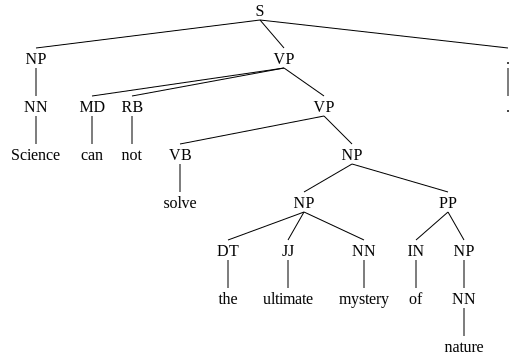

In [24]:
import nltk
benepar.download('benepar_en3')
nlp = spacy.load('en_core_web_sm')
nlp.add_pipe('benepar', config={'model': 'benepar_en3'})
doc = nlp('Science cannot solve the ultimate mystery of nature.')
sent = list(doc.sents)[0]
print(sent._.parse_string)
print(sent._.labels)
print(list(sent._.children)[0])
nltk.Tree.fromstring(sent._.parse_string)

# Application
## Unsupervised Discovery of Gendered Language through Latent-Variable Modeling

[Hoyle et al. (2019)](https://www.aclweb.org/anthology/P19-1167/) study the language use of gendered nouns and proceed to train a generative latent-variable model that jointly represents adjective (or verb) choice, with its sentiment given the (natural) gender of a noun. To this extent, they extract noun–adjectives pairs, NSUBJ–verb pairs and DOBJ–verb pairs. 

In the following, we show how to extract NSUBJ-verb pairs from text.

In [32]:
df

,court_id,author_id,state,year,dateFiled,citeCount,snippet
9964,fla,NaN,FL,1996,1996-11-27T00:00:00Z,21,established with the understanding that each d...
18305,texcrimapp,NaN,TX,1926,1926-11-10T00:00:00Z,1,"evidence adduced, overturn a verdict assessing..."
29636,texapp,NaN,TX,2007,2007-04-05T00:00:00Z,0,\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n . The...
25749,pa,5527.0,PA,2015,2015-06-16T00:00:00Z,0,intellectually disabled and exempt\n\nfrom the...
9314,texapp,8394.0,TX,2001,2001-04-30T00:00:00Z,10,all criminal cases except those in which the d...
...,...,...,...,...,...,...,...
30598,wva,NaN,WV,2016,2016-06-16T00:00:00Z,0,Nicholas Varlas\n\n\n\n June \n\n\n\nFelony ...
17119,fla,NaN,FL,2015,2015-10-29T00:00:00Z,0,to the death penalty but instead stated firml...
30152,mdctspecapp,NaN,MD,2012,2012-05-10T00:00:00Z,1,Chair of the Governor&# ;s Commission on the D...
20463,txed,633.0,TX,2007,2007-08-24T00:00:00Z,5,against Vista would be tantamount to a &quot;D...


In [39]:
import importlib
import benepar.retokenization
importlib.reload(benepar.retokenization)
# Reload ensures the fixed retokenization.py is active in this session.

<module 'benepar.retokenization' from '/opt/anaconda3/envs/tad_courses/lib/python3.11/site-packages/benepar/retokenization.py'>

In [40]:
df = df.sample(n=200)
df["processed"] = df["snippet"].apply(lambda x: nlp(x)) # takes many time so we sample 200 data points


In [41]:

def extract_subject_verb_pairs(sent):
    subjs = [w for w in sent if w.dep_ == "nsubj"]
    pairs = [(w.lemma_.lower(), w.head.lemma_.lower()) for w in subjs]
    return pairs

df["subj-verb-pairs"] = df["processed"].apply(lambda x: extract_subject_verb_pairs(x))

In [51]:
# most common pairs
counter = Counter()
for item in df["subj-verb-pairs"]:
    counter.update(item)
    
for pair, counts in counter.most_common(n=25):
    print (pair, counts)

('penalty', 'be') 22
('state', 'seek') 16
('jury', 'recommend') 8
('he', 'be') 7
('defendant', 'be') 7
('statute', 'be') 7
('court', 'find') 7
('it', 'be') 6
('jury', 'find') 6
('this', 'be') 5
('court', 'sentence') 4
('he', 'vote') 4
('court', 'hold') 4
('defendant', 'waive') 4
('arizona', 'be') 3
('scheme', 'be') 3
('he', 'receive') 3
('jury', 'impose') 3
('they', 'be') 3
('which', 'provide') 3
('counsel', 'be') 3
('jury', 'return') 3
('s', 'be') 2
('decision', 'be') 2
('which', 'permit') 2


In [52]:
# Patch: transformers 5.x requires all_tied_weights_keys on PreTrainedModel subclasses;
# fastcoref's FCorefModel doesn't define it.
from fastcoref.modeling.modeling_fcoref import FCorefModel
if not hasattr(FCorefModel, 'all_tied_weights_keys'):
    FCorefModel.all_tied_weights_keys = property(lambda self: [])

ModuleNotFoundError: No module named 'fastcoref.modeling.modeling_fcoref'; 'fastcoref.modeling' is not a package

In [ ]:
nlp.add_pipe("fastcoref")
# to load a more accurate model:
# nlp.add_pipe("fastcoref", config={'model_architecture': 'LingMessCoref', 'model_path': 'biu-nlp/lingmess-coref', 'device': 'cpu'})

05/15/2026 15:14:51 - INFO - 	 HTTP Request: HEAD https://huggingface.co/biu-nlp/f-coref/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
05/15/2026 15:14:51 - INFO - 	 HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/biu-nlp/f-coref/e91dfff12879495d882ba9460d0c5d5dd44ade59/config.json "HTTP/1.1 200 OK"
05/15/2026 15:14:52 - INFO - 	 HTTP Request: HEAD https://huggingface.co/biu-nlp/f-coref/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
05/15/2026 15:14:52 - INFO - 	 HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/biu-nlp/f-coref/e91dfff12879495d882ba9460d0c5d5dd44ade59/config.json "HTTP/1.1 200 OK"
05/15/2026 15:14:52 - INFO - 	 HTTP Request: HEAD https://huggingface.co/biu-nlp/f-coref/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
05/15/2026 15:14:52 - INFO - 	 HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/biu-nlp/f-coref/e91dfff12879495d882ba9460d0c5d5dd44ade59/tokenizer_config.json

Loading weights:   0%|          | 0/133 [00:00<?, ?it/s]

[transformers] FCorefModel LOAD REPORT from: biu-nlp/f-coref
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
05/15/2026 15:14:52 - INFO - 	 HTTP Request: GET https://huggingface.co/api/models/biu-nlp/f-coref "HTTP/1.1 200 OK"


AttributeError: 'FCorefModel' object has no attribute 'all_tied_weights_keys'

05/15/2026 15:14:52 - INFO - 	 HTTP Request: GET https://huggingface.co/api/models/biu-nlp/f-coref/commits/main "HTTP/1.1 200 OK"


05/15/2026 15:14:53 - INFO - 	 HTTP Request: GET https://huggingface.co/api/models/biu-nlp/f-coref/discussions?p=0 "HTTP/1.1 200 OK"
05/15/2026 15:14:53 - INFO - 	 HTTP Request: GET https://huggingface.co/api/models/biu-nlp/f-coref/commits/refs%2Fpr%2F1 "HTTP/1.1 200 OK"
05/15/2026 15:14:53 - INFO - 	 HTTP Request: HEAD https://huggingface.co/biu-nlp/f-coref/resolve/refs%2Fpr%2F1/model.safetensors.index.json "HTTP/1.1 404 Not Found"
05/15/2026 15:14:53 - INFO - 	 HTTP Request: HEAD https://huggingface.co/biu-nlp/f-coref/resolve/refs%2Fpr%2F1/model.safetensors "HTTP/1.1 302 Found"


In [ ]:
# Coreference Resolution
example = 'My sister has a dog. She loves him.'
doc = nlp(example)
print(doc._.coref_clusters)   
resolved_corefs = [[example[t[0]:t[1]] for t in c] for c in doc._.coref_clusters]
print(resolved_corefs)
# directly load resolved texts
docs = nlp.pipe(
   ['My sister has a dog. She loves him.'], 
   component_cfg={"fastcoref": {'resolve_text': True}}
)
print(list(docs)[0]._.resolved_text)

AttributeError: [E046] Can't retrieve unregistered extension attribute 'coref_clusters'. Did you forget to call the `set_extension` method?

AttributeError: [E046] Can't retrieve unregistered extension attribute 'coref_clusters'. Did you forget to call the `set_extension` method?

In [38]:
docs = nlp.pipe(
    df["snippet"],
    component_cfg={"fastcoref": {'resolve_text': True}}
)
df["resolved_texts"] = [doc._.resolved_text for doc in docs]
# df["resolved_texts"] = df["snippet"].apply(lambda x: nlp(x))


AttributeError: [E046] Can't retrieve unregistered extension attribute 'resolved_text'. Did you forget to call the `set_extension` method?

In [54]:
nlp = spacy.load('en_core_web_sm')
# nlp.add_pipe('benepar', config={'model': 'benepar_en3'})

df["resolved_processed"] = df["resolved_texts"].apply(lambda x: nlp(x))

KeyError: 'resolved_texts'

In [55]:
df["resovled_subj-verb-pairs"] = df["resolved_processed"].apply(lambda x: extract_subject_verb_pairs(x))
# most common pairs
counter = Counter()
for item in df["resovled_subj-verb-pairs"]:
    counter.update(item)
    
for pair, counts in counter.most_common(n=25):
    print (pair, counts)

KeyError: 'resolved_processed'

In [56]:
# verbs used with defendant

for (subject, verb), counts in counter.most_common():
    if subject == "defendant" and counts > 1:
        print (subject, verb, counts)

defendant be 7
defendant waive 4
defendant contend 2
defendant eligible 2


In [57]:
# verbs used with jury

for (subject, verb), counts in counter.most_common():
    if subject == "jury" and counts > 1:
        print (subject, verb, counts)

jury recommend 8
jury find 6
jury impose 3
jury return 3
